# DATA

## EXTRACCION DE DATOS
Para el desarrollo de este proyecto se recurrió a dos tipos de fuentes. Por un lado, las pistas de audio utilizadas para construir el dataset fueron obtenidas de Free Music Archive (https://freemusicarchive.org), plataforma de distribución musical que ofrece canciones bajo licencias Creative Commons, permitiendo su uso libre en contextos académicos e investigativos sin restricciones de derechos de autor. Las canciones fueron seleccionadas y organizadas manualmente por género musical, garantizando un mínimo de 50 pistas por categoría.

## PROCESAMIENTO Y MODELAMIENTO DE LOS DATOS

### Librerias 
Librosa: es una librería especializada en análisis de audio y música que permite cargar archivos de sonido y extraer características acústicas. Es el núcleo del proceso de extracción de features en este proyecto.

NumPy: es la librería fundamental para computación numérica en Python. Proporciona estructuras de datos tipo array de alto rendimiento y operaciones matemáticas vectorizadas, siendo la base sobre la que trabajan la mayoría de librerías científicas incluyendo Librosa.

Pandas es la librería estándar para manipulación y análisis de datos tabulares en Python. Permite construir, limpiar y transformar dataframes, que es la estructura utilizada para almacenar y exportar el dataset final en formato CSV.

Os es un módulo nativo de Python que permite interactuar con el sistema operativo, específicamente con el sistema de archivos. En este proyecto se utiliza para recorrer las carpetas de géneros, listar los archivos de audio disponibles y construir las rutas de acceso a cada canción.

### Extracción de Features 
El código implementa un pipeline de extracción automática de características acústicas a partir de archivos de audio organizados por género musical. Para cada canción se carga la pista completa y se extraen tres segmentos de 30 segundos correspondientes al inicio, la mitad y el final de la pista. De cada segmento se calculan 27 features: siete características acústicas globales (tempo, spectral centroid, spectral bandwidth, rolloff, zero crossing rate, RMS energy y chroma STFT) y 20 coeficientes MFCC que representan el timbre de la señal. Cada segmento procesado queda registrado como una fila independiente en el dataset, junto con su etiqueta de género y el nombre del archivo de origen. El resultado final es un archivo CSV estructurado y listo para la etapa de modelado.

In [23]:
import librosa
import numpy as np
import pandas as pd
import os
import warnings
from tqdm import tqdm

warnings.filterwarnings('ignore')

def extraerfeatures(y, sr):
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    
    features = {
        'tempo':               librosa.beat.tempo(y=y, sr=sr)[0],
        'spectral_centroid':   librosa.feature.spectral_centroid(y=y, sr=sr).mean(),
        'spectral_bandwidth':  librosa.feature.spectral_bandwidth(y=y, sr=sr).mean(),
        'rolloff':             librosa.feature.spectral_rolloff(y=y, sr=sr).mean(),
        'zero_crossing_rate':  librosa.feature.zero_crossing_rate(y).mean(),
        'rms':                 librosa.feature.rms(y=y).mean(),
        'chroma_stft':         chroma.mean(),
        'onset_strength_mean': onset_env.mean(),
        'onset_strength_std':  onset_env.std(),
        'pitch_variance':      chroma.var(),
        'spectral_flux_std':   onset_env.std() 
    }
    
    for i, coef in enumerate(mfccs):
        features[f'mfcc{i+1}_mean'] = coef.mean()
        features[f'mfcc{i+1}_std']  = coef.std()
        
    return features

# --- CONFIGURACIÓN ---
filas = []
carpeta_raiz = 'data/raw/songs' 

# Contadores para el reporte
stats = {"procesados": 0, "error_lectura": 0, "muy_cortos": 0}

generos = [d for d in os.listdir(carpeta_raiz) if os.path.isdir(os.path.join(carpeta_raiz, d))]

for genero in generos:
    carpeta_genero = os.path.join(carpeta_raiz, genero)
    archivos_genero = [f for f in os.listdir(carpeta_genero) if f.endswith(('.mp3', '.wav'))]
    
    for archivo in tqdm(archivos_genero, desc=f"Procesando {genero}"):
        ruta = os.path.join(carpeta_genero, archivo)
        try:
            # Cargamos el audio
            y, sr = librosa.load(ruta, sr=None)
            duracion = librosa.get_duration(y=y, sr=sr)

            # LÓGICA DE SEGMENTACIÓN DINÁMICA: Rescata canciones cortas
            puntos_segmento = []
            
            if duracion >= 85:
                # Caso estándar: 3 segmentos
                puntos_segmento = [
                    (0, "inicio"), 
                    (int(duracion/2)-15, "mitad"), 
                    (int(duracion)-30, "final")
                ]
            elif duracion >= 60:
                # Rescate: 2 segmentos
                puntos_segmento = [(0, "inicio"), (int(duracion)-30, "final")]
            elif duracion >= 30:
                # Rescate mínimo: 1 segmento
                puntos_segmento = [(0, "unico")]
            else:
                stats["muy_cortos"] += 1
                continue

            for inicio_seg, nombre_seg in puntos_segmento:
                inicio_p = int(inicio_seg * sr)
                fin_p    = int((inicio_seg + 30) * sr)
                segmento = y[inicio_p:fin_p]

                # Margen de seguridad de 29s para evitar errores de redondeo
                if len(segmento) >= int(29 * sr): 
                    features = extraerfeatures(segmento, sr)
                    features['label'] = genero
                    features['song_id'] = archivo
                    features['segment_type'] = nombre_seg
                    filas.append(features)
            
            stats["procesados"] += 1

        except Exception:
            stats["error_lectura"] += 1
            continue

# CREACIÓN DEL DATAFRAME
df = pd.DataFrame(filas)

# --- REPORTE FINAL ---
print(f"\n--- RESUMEN DEL PROCESO ACTUALIZADO ---")
print(f"Canciones procesadas con éxito: {stats['procesados']}")
print(f"Canciones saltadas (menos de 30s): {stats['muy_cortos']}")
print(f"Canciones con error de archivo: {stats['error_lectura']}")
print(f"Total de segmentos en el DataFrame: {df.shape[0]}")
print(f"\nDistribución por género:\n{df['label'].value_counts()}")

Procesando pop:  26%|██▌       | 13/50 [00:23<01:06,  1.80s/it][src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?
[src/libmpg123/id3.c:process_extra():684] error: No extra frame text / valid description?
[src/libmpg123/id3.c:process_extra():684] error: No extra frame text / valid description?
[src/libmpg123/id3.c:process_extra():684] error: No extra frame text / valid description?
[src/libmpg123/id3.c:process_extra():684] error: No extra frame text / valid description?
[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?
Procesando pop:  32%|███▏      | 16/50 [00:29<01:04,  1.89s/it][src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?
[src/libmpg123/id3.c:process_extra():684] error: No extra frame text / valid description?
[src/libmpg123/id3.c:process_extra():684] error: No extra frame text / valid description?
[src/libmpg123/id3.c:process_extra():684] error: No extra frame text /


--- RESUMEN DEL PROCESO ACTUALIZADO ---
Canciones procesadas con éxito: 332
Canciones saltadas (menos de 30s): 1
Canciones con error de archivo: 17
Total de segmentos en el DataFrame: 979

Distribución por género:
label
clasicc        150
Electronica    150
jazz           148
Vallenato      147
pop            147
Rock           144
Hip-Hop         93
Name: count, dtype: int64


## RESULTADOS

In [24]:
df.head(3)

,tempo,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,rms,chroma_stft,onset_strength_mean,onset_strength_std,pitch_variance,...,mfcc10_std,mfcc11_mean,mfcc11_std,mfcc12_mean,mfcc12_std,mfcc13_mean,mfcc13_std,label,song_id,segment_type
0,140.625000,3155.401300,3505.616624,6743.451164,0.059765,0.176762,0.401536,1.397984,1.720091,0.095407,...,11.798267,-5.197709,11.800679,-4.573185,10.176497,1.182906,9.940129,Vallenato,Jose Carrascal - Como Duele El Frio.mp3,inicio
1,144.230769,3213.328268,3507.036509,6884.226138,0.071339,0.207555,0.317630,1.413439,1.547582,0.089780,...,10.543764,-4.728733,11.399025,-3.438390,9.680881,4.272985,10.252098,Vallenato,Jose Carrascal - Como Duele El Frio.mp3,mitad
2,140.625000,3506.135640,3881.860700,8020.240846,0.064768,0.120561,0.457444,1.188929,1.534752,0.093239,...,9.591031,-4.801034,9.903723,2.310814,7.824638,3.756548,9.018738,Vallenato,Jose Carrascal - Como Duele El Frio.mp3,final


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 979 entries, 0 to 978
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   tempo                979 non-null    float64
 1   spectral_centroid    979 non-null    float64
 2   spectral_bandwidth   979 non-null    float64
 3   rolloff              979 non-null    float64
 4   zero_crossing_rate   979 non-null    float64
 5   rms                  979 non-null    float32
 6   chroma_stft          979 non-null    float32
 7   onset_strength_mean  979 non-null    float32
 8   onset_strength_std   979 non-null    float32
 9   pitch_variance       979 non-null    float32
 10  spectral_flux_std    979 non-null    float32
 11  mfcc1_mean           979 non-null    float32
 12  mfcc1_std            979 non-null    float32
 13  mfcc2_mean           979 non-null    float32
 14  mfcc2_std            979 non-null    float32
 15  mfcc3_mean           979 non-null    float32
 16  m

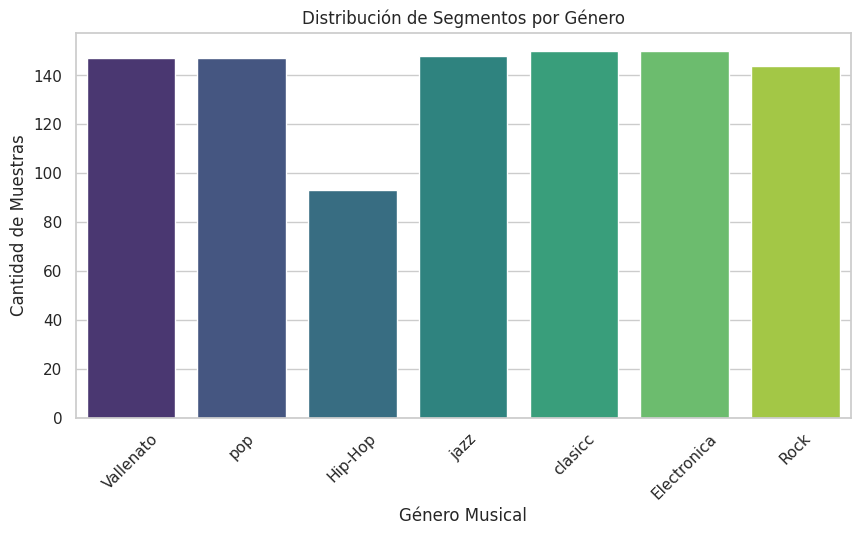

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Distribución de Segmentos por Género')
plt.xlabel('Género Musical')
plt.ylabel('Cantidad de Muestras')
plt.xticks(rotation=45)
plt.show()

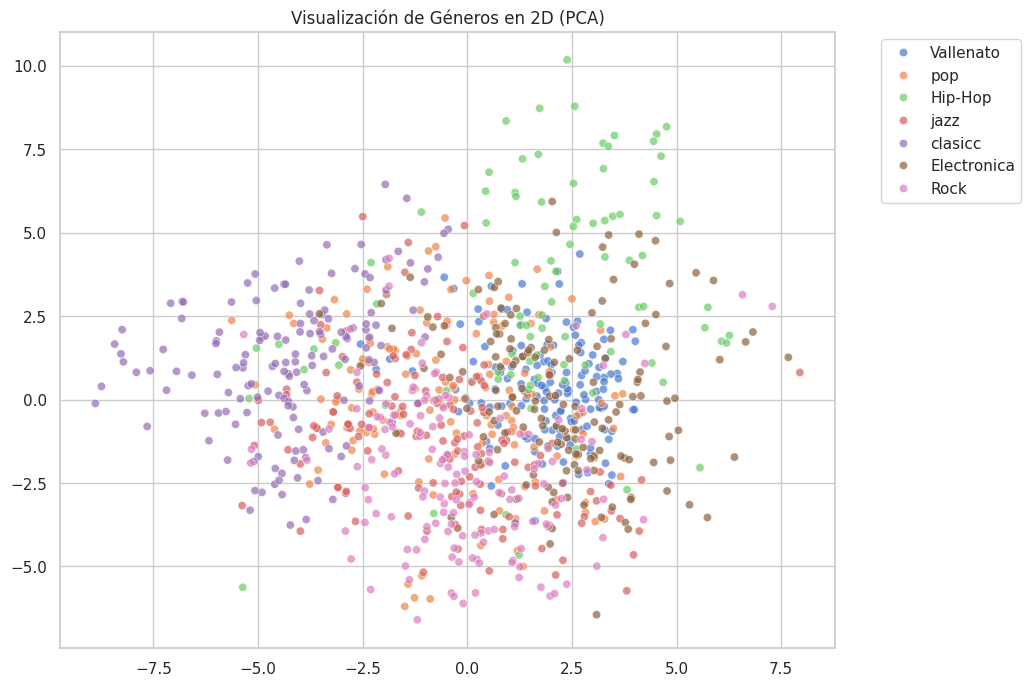

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Normalizar los datos
features = df.select_dtypes(include=[np.number]).columns
x = StandardScaler().fit_transform(df[features])

# 2. Aplicar PCA
pca = PCA(n_components=2)
components = pca.fit_transform(x)

# 3. Graficar
plt.figure(figsize=(10, 8))
sns.scatterplot(x=components[:,0], y=components[:,1], hue=df['label'], alpha=0.7)
plt.title('Visualización de Géneros en 2D (PCA)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

In [28]:
df

,tempo,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,rms,chroma_stft,onset_strength_mean,onset_strength_std,pitch_variance,...,mfcc10_std,mfcc11_mean,mfcc11_std,mfcc12_mean,mfcc12_std,mfcc13_mean,mfcc13_std,label,song_id,segment_type
0,140.625000,3155.401300,3505.616624,6743.451164,0.059765,0.176762,0.401536,1.397984,1.720091,0.095407,...,11.798267,-5.197709,11.800679,-4.573185,10.176497,1.182906,9.940129,Vallenato,Jose Carrascal - Como Duele El Frio.mp3,inicio
1,144.230769,3213.328268,3507.036509,6884.226138,0.071339,0.207555,0.317630,1.413439,1.547582,0.089780,...,10.543764,-4.728733,11.399025,-3.438390,9.680881,4.272985,10.252098,Vallenato,Jose Carrascal - Como Duele El Frio.mp3,mitad
2,140.625000,3506.135640,3881.860700,8020.240846,0.064768,0.120561,0.457444,1.188929,1.534752,0.093239,...,9.591031,-4.801034,9.903723,2.310814,7.824638,3.756548,9.018738,Vallenato,Jose Carrascal - Como Duele El Frio.mp3,final
3,106.132075,1218.458957,1727.177589,2264.472427,0.029935,0.057680,0.352242,0.788208,0.869112,0.089632,...,8.998346,-4.526205,9.687932,-3.235842,7.369473,-1.635380,8.995258,Vallenato,Felipe Pelaez - Cuando Quieras Quiero.mp3,inicio
4,108.173077,1376.386515,1841.321934,2601.412527,0.033015,0.106468,0.345141,0.827019,0.713452,0.082585,...,9.183265,-3.056041,8.695364,-2.189327,7.418135,-1.961334,8.530977,Vallenato,Felipe Pelaez - Cuando Quieras Quiero.mp3,mitad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
974,114.843750,2024.523089,2983.804248,4145.224934,0.023254,0.056747,0.696962,1.213672,1.615181,0.053116,...,8.046965,-0.315271,10.783252,9.442097,8.852472,8.264495,9.224631,Rock,Jon Shuemaker - No Power in the Darkness.mp3,mitad
975,112.347147,3888.927775,3855.941674,7703.161753,0.091530,0.035595,0.629231,1.263877,1.927206,0.069629,...,9.005262,2.274001,8.447702,3.809188,6.649044,-0.711357,7.162637,Rock,Jon Shuemaker - No Power in the Darkness.mp3,final
976,129.199219,2588.170044,2566.728210,4819.395858,0.072782,0.276869,0.539660,0.961135,0.766532,0.062263,...,6.727568,4.259280,7.396950,-1.971420,6.087136,2.025295,5.374858,Rock,June Ryah - Used to happen.mp3.mp3,inicio
977,129.199219,2972.525423,3022.852407,5684.015630,0.077990,0.294631,0.460888,1.039280,0.644826,0.079493,...,7.665515,-0.272055,7.163309,2.561832,7.105761,2.262244,6.568953,Rock,June Ryah - Used to happen.mp3.mp3,mitad


In [29]:
df.to_csv('datav1.csv', index=False)